# Stage 12B — Event Diagnostics

**Research question:** What exactly are the events in our sample?

The detector identifies statistical shocks, not economic news. This notebook audits concentration, large observations, pre-event volatility, abnormal volume, and peer coverage without deleting unusual events.

## Methodology

All calculations live in `price_diffusion.research_diagnostics`. Volume percentiles use only the initiator's prior 252 observations. Market-cap coverage is reported as observed; missing values are not imputed.

In [1]:
from IPython.display import Image, display
from price_diffusion.research_diagnostics import load_diagnostic_inputs, run_event_diagnostics

inputs = load_diagnostic_inputs()
artifacts = run_event_diagnostics(inputs)

In [2]:
display(artifacts.tables['event_summary'])
display(artifacts.tables['largest_events'])
display(artifacts.tables['event_concentration'])

,dimension,label,event_count,event_share
0,total,all,242,1.000000
1,year,2015,14,0.057851
2,year,2016,16,0.066116
3,year,2017,7,0.028926
4,year,2018,16,0.066116
...,...,...,...,...
129,subsector,fabless_compute,42,0.173554
130,subsector,foundry,29,0.119835
131,subsector,semiconductor_equipment,62,0.256198
132,direction,negative,102,0.421488


,event_date,initiator,company_name,subsector,relative_shock_magnitude,z_score,market_cap,volume_percentile,abnormal_volume_ratio,peer_return,initiator_return,peer_count,peer_portfolio_coverage
188,2024-12-03,CRDO,Credo Technology Group Holding Ltd.,fabless_compute,0.478408,16.888317,NaN,1.000000,8.374456,0.000462,0.478870,3,1.0
160,2024-05-30,CRDO,Credo Technology Group Holding Ltd.,fabless_compute,0.275123,10.454143,NaN,1.000000,5.980126,-0.004599,0.270524,3,1.0
233,2025-10-06,AMD,Advanced Micro Devices Inc.,fabless_compute,0.222112,8.701085,NaN,1.000000,6.453811,0.014968,0.237080,3,1.0
128,2023-06-01,CRDO,Credo Technology Group Holding Ltd.,fabless_compute,0.197005,6.294727,NaN,0.992063,7.753288,0.035484,0.232489,3,1.0
133,2023-10-30,ON,onsemi,analog_mixed_signal,-0.191018,-14.960735,NaN,1.000000,7.092176,-0.026655,-0.217672,8,1.0
190,2024-12-03,MRVL,Marvell Technology Inc.,fabless_compute,-0.173163,-8.179742,NaN,0.972222,2.399294,0.163355,-0.009808,3,1.0
26,2016-09-29,NXPI,NXP Semiconductors N.V.,analog_mixed_signal,0.169998,14.682794,NaN,0.988095,7.306173,-0.001224,0.168774,8,1.0
11,2015-10-29,NXPI,NXP Semiconductors N.V.,analog_mixed_signal,-0.165312,-10.279901,NaN,1.000000,11.939831,-0.031784,-0.197096,8,1.0
123,2023-05-25,MPWR,Monolithic Power Systems Inc.,analog_mixed_signal,0.165149,7.120447,NaN,0.992063,4.173092,0.009460,0.174608,8,1.0
187,2024-12-03,AMD,Advanced Micro Devices Inc.,fabless_compute,-0.160837,-6.795734,NaN,0.015873,0.462223,0.160273,-0.000563,3,1.0


,dimension,category_count,largest_category,largest_category_share,herfindahl_index,effective_category_count,event_count
0,year,11,2024,0.214876,0.131104,7.627507,242
1,month,95,2025-08,0.041322,0.017246,57.984158,242
2,company,21,STM,0.099174,0.062257,16.062534,242
3,subsector,4,analog_mixed_signal,0.450413,0.312991,3.194981,242
4,direction,2,positive,0.578512,0.512328,1.951873,242


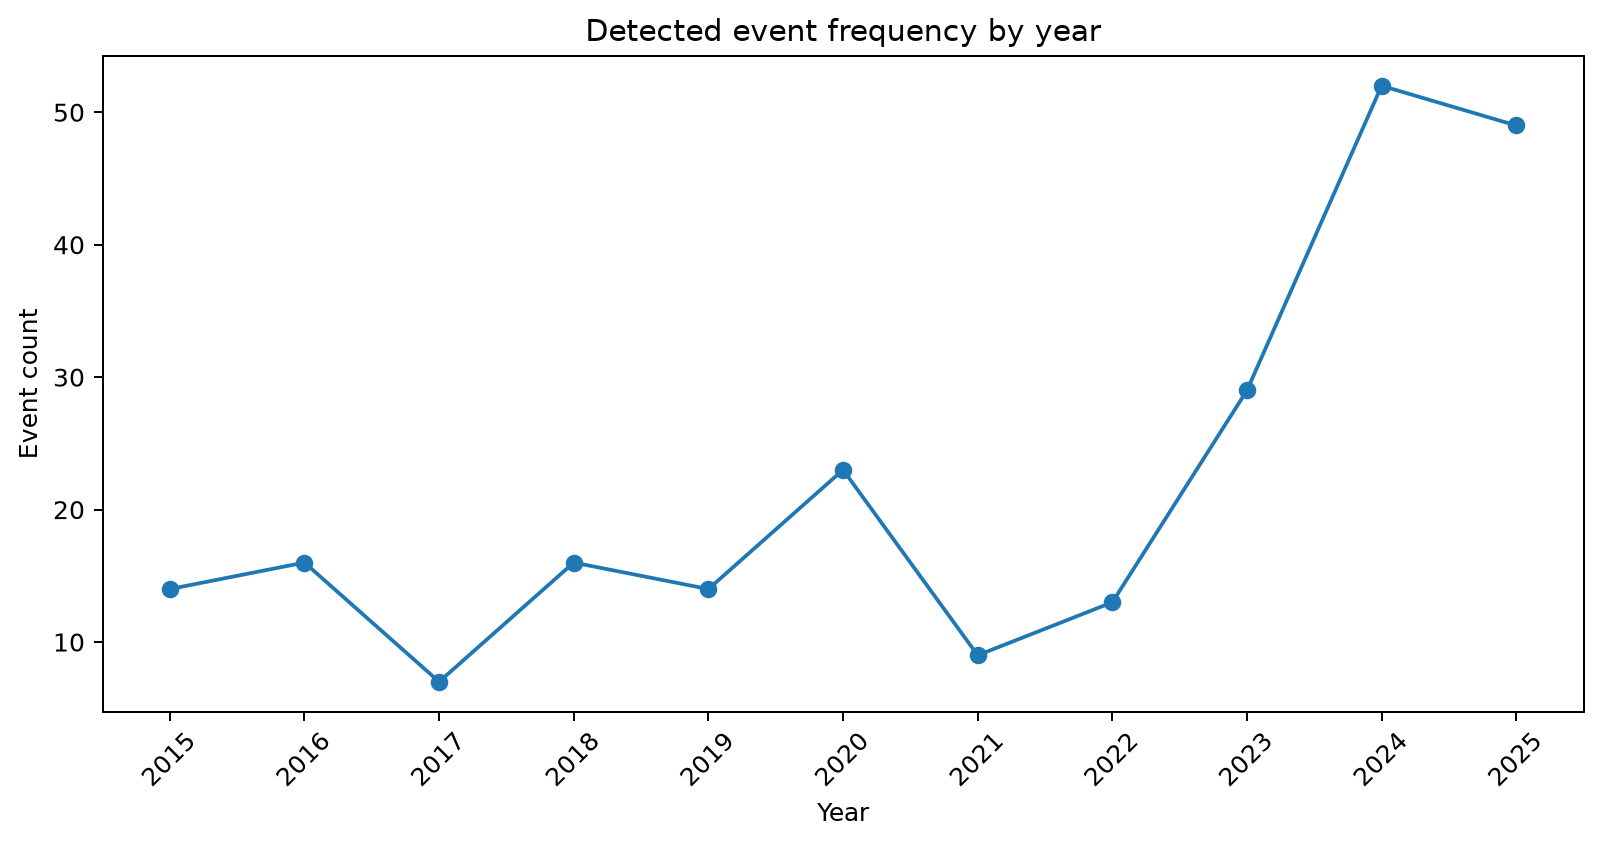

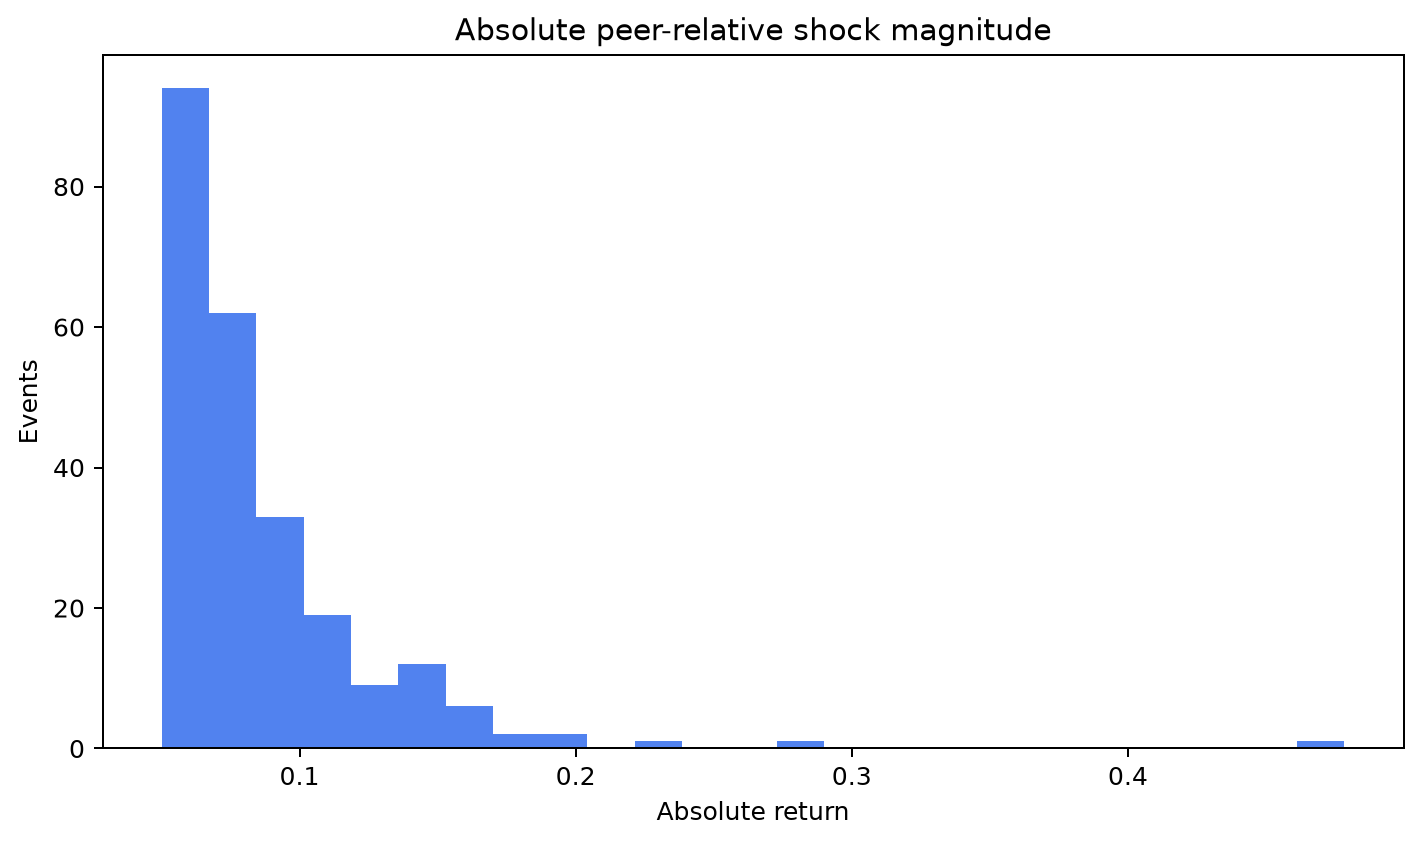

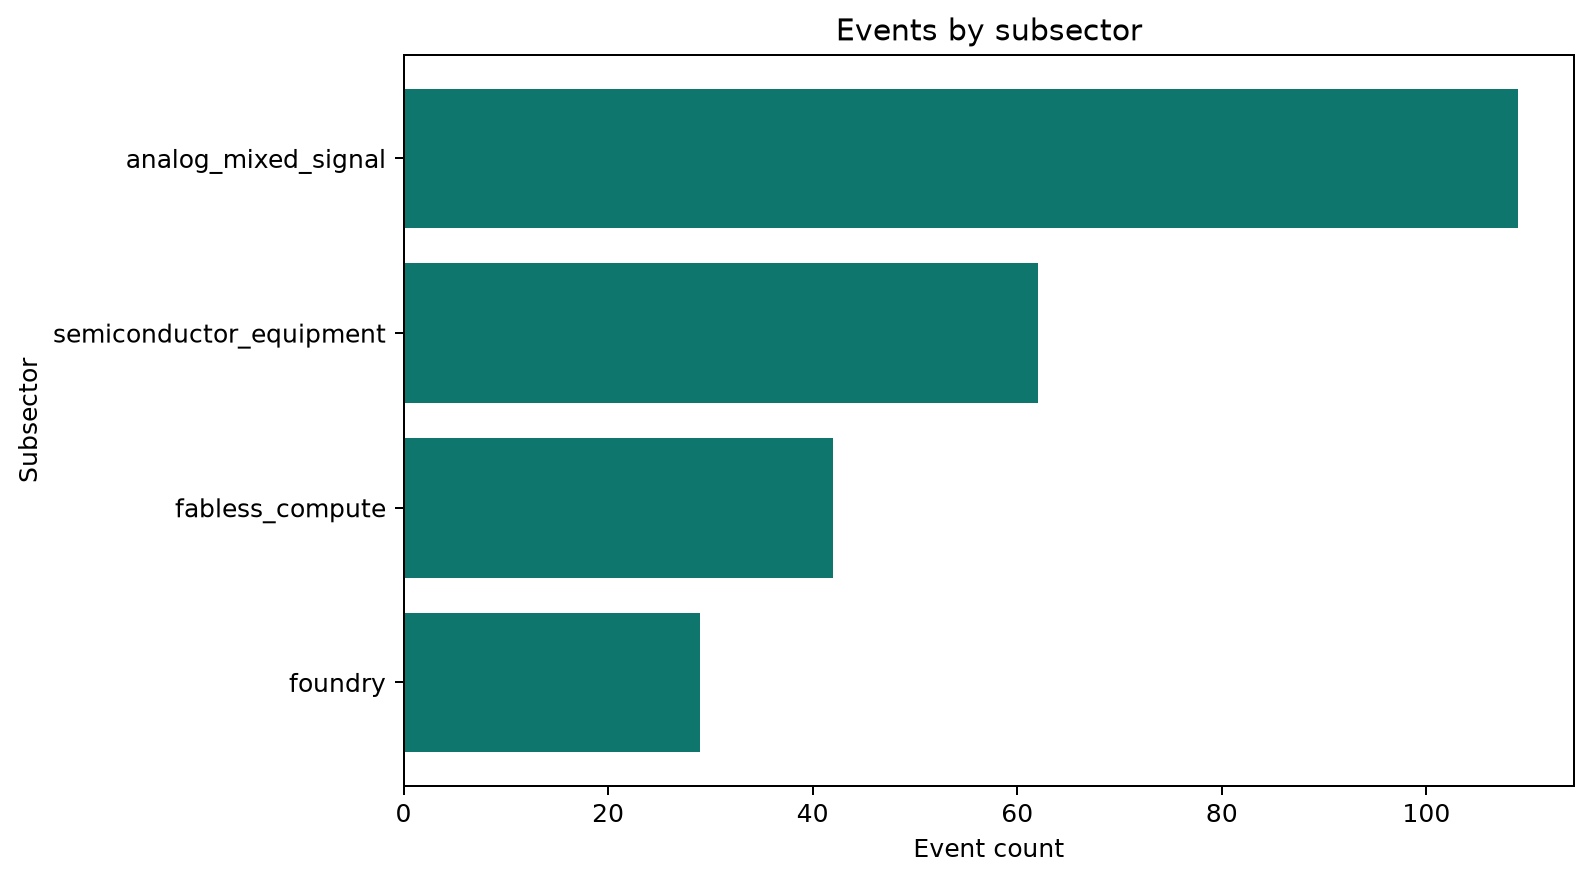

In [3]:
for name in ('event_frequency_over_time', 'shock_magnitude_distribution', 'events_by_subsector'):
    display(Image(filename=str(artifacts.paths[name])))

## Interpretation

Read concentration jointly across time, initiator, and subsector. A large z-score can still be a low-dollar or thinly covered event. These diagnostics describe the detected sample and do not justify post-hoc exclusions.